Import Libraries

In [1]:
# ===========================
# TASK 6 - MACHINE LEARNING
# Import Required Libraries
# ===========================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)


Load Dataset

In [2]:
# ===========================
# Load Dataset
# ===========================

df = pd.read_csv("E-commerce Customer Behavior - Sheet1.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (350, 11)


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


Dataset Information

In [3]:
# ===========================
# Dataset Information
# ===========================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


Statistical Summary

In [4]:
# ===========================
# Statistical Summary
# ===========================

df.describe(include='all')

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
count,350.000000,350,350.000000,350,350,350.000000,350.000000,350.000000,350,350.000000,348
unique,NaN,2,NaN,6,3,NaN,NaN,NaN,2,NaN,3
top,NaN,Female,NaN,New York,Gold,NaN,NaN,NaN,True,NaN,Satisfied
freq,NaN,175,NaN,59,117,NaN,NaN,NaN,175,NaN,125
mean,275.500000,NaN,33.597143,NaN,NaN,845.381714,12.600000,4.019143,NaN,26.588571,NaN
std,101.180532,NaN,4.870882,NaN,NaN,362.058695,4.155984,0.580539,NaN,13.440813,NaN
min,101.000000,NaN,26.000000,NaN,NaN,410.800000,7.000000,3.000000,NaN,9.000000,NaN
25%,188.250000,NaN,30.000000,NaN,NaN,502.000000,9.000000,3.500000,NaN,15.000000,NaN
50%,275.500000,NaN,32.500000,NaN,NaN,775.200000,12.000000,4.100000,NaN,23.000000,NaN
75%,362.750000,NaN,37.000000,NaN,NaN,1160.600000,15.000000,4.500000,NaN,38.000000,NaN


Missing Values

In [5]:
# ===========================
# Missing Values
# ===========================

df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

Data Visualization

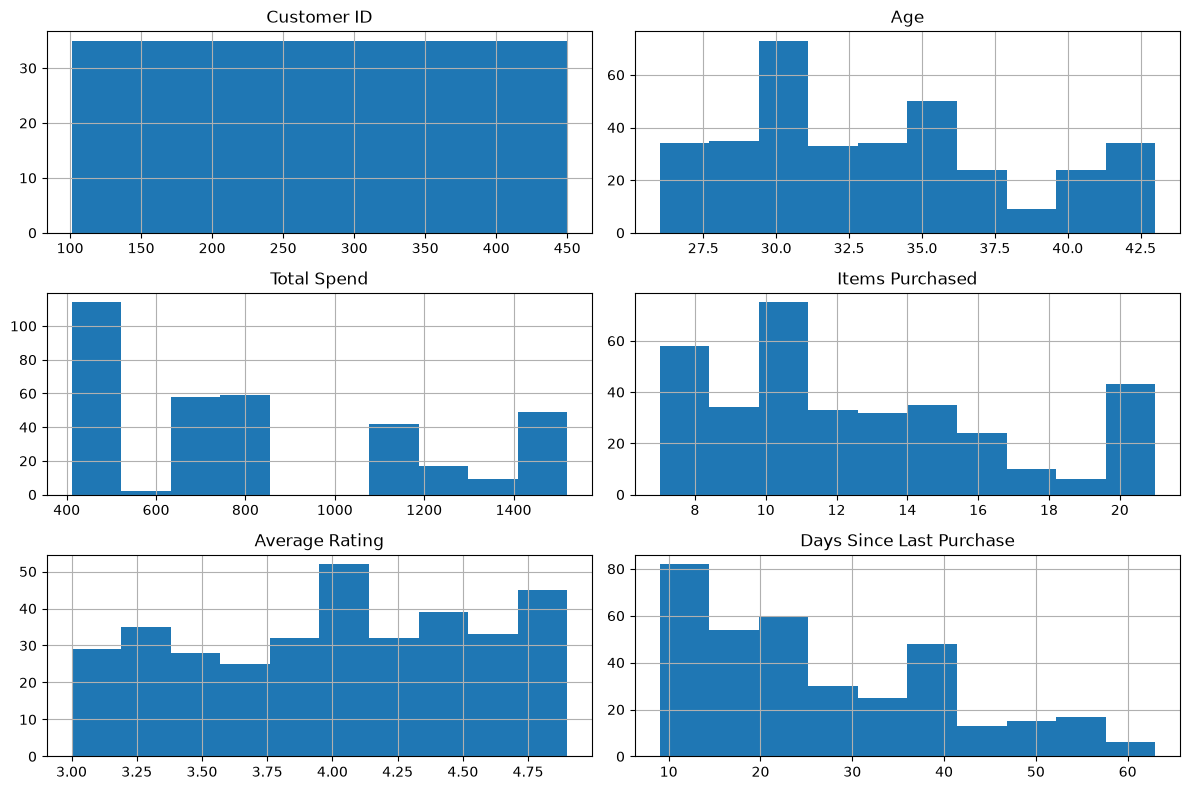

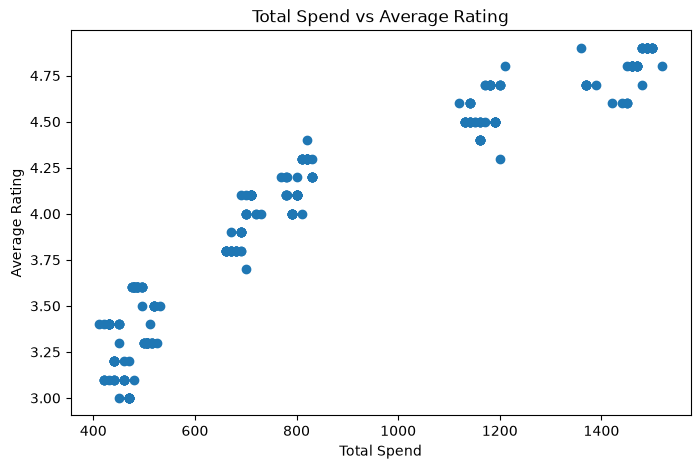

In [6]:
# ===========================
# Data Visualization
# ===========================

# Histogram of Numerical Features
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Total Spend vs Average Rating
plt.figure(figsize=(8,5))
plt.scatter(df["Total Spend"], df["Average Rating"])
plt.xlabel("Total Spend")
plt.ylabel("Average Rating")
plt.title("Total Spend vs Average Rating")
plt.show()

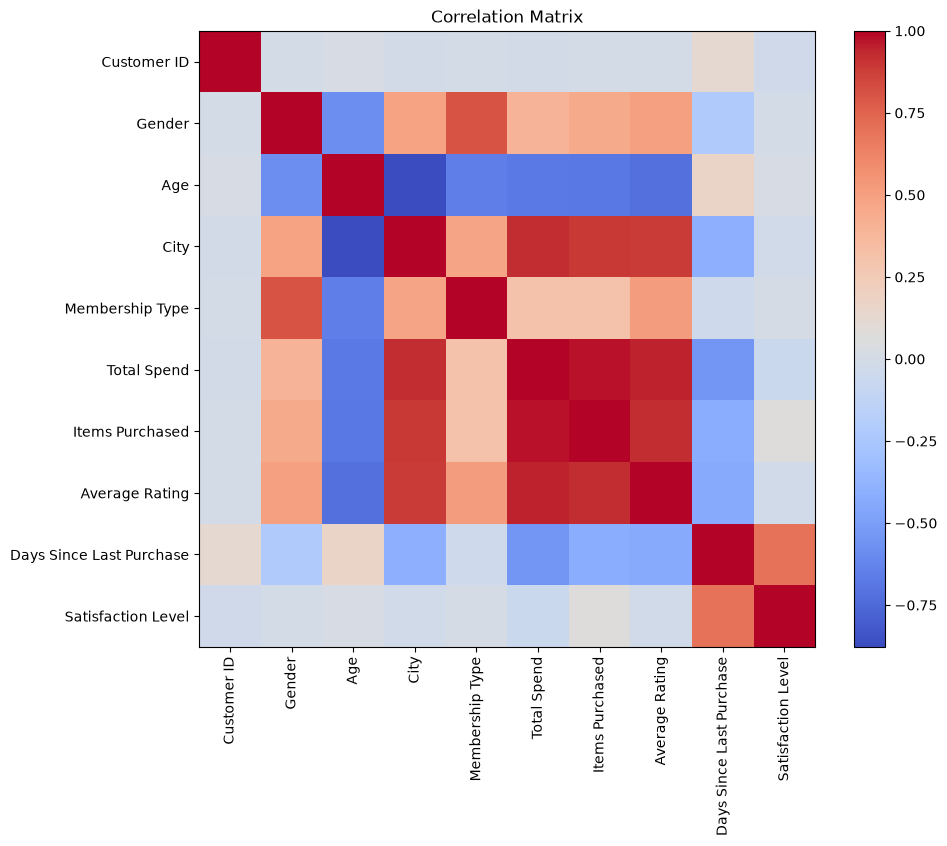

In [21]:
# Correlation Matrix

plt.figure(figsize=(10,8))

numeric_df = data.select_dtypes(include=['number'])

plt.imshow(numeric_df.corr(), cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Matrix")

plt.show()

Data Preprocessing (Label Encoding)

In [7]:
# ===========================
# Label Encoding
# ===========================

# Create a copy of the dataset
data = df.copy()

# Store encoders if needed later
encoders = {}

categorical_columns = data.select_dtypes(include=['object']).columns

for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    encoders[column] = le

print("Categorical columns encoded successfully!")

data.head()

Categorical columns encoded successfully!


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,0,29,4,1,1120.20,14,4.6,True,25,1
1,102,1,34,2,2,780.50,11,4.1,False,18,0
2,103,0,43,0,0,510.75,9,3.4,True,42,2
3,104,1,30,5,1,1480.30,19,4.7,False,12,1
4,105,1,27,3,2,720.40,13,4.0,True,55,2


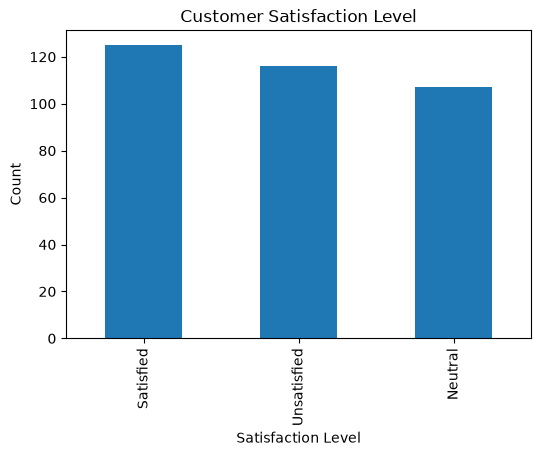

In [22]:
# Distribution of Satisfaction Level

plt.figure(figsize=(6,4))

df["Satisfaction Level"].value_counts().plot(kind="bar")

plt.title("Customer Satisfaction Level")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")

plt.show()

Feature Scaling

In [8]:
# ===========================
# Feature Scaling
# ===========================

scaler = StandardScaler()

scaled_data = data.copy()

# Do not scale target columns
columns_to_scale = scaled_data.drop(
    columns=["Average Rating", "Discount Applied"]
).columns

scaled_data[columns_to_scale] = scaler.fit_transform(
    scaled_data[columns_to_scale]
)

scaled_data.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,-1.727109,-1.0,-0.945152,0.878073,-0.003502,0.760130,0.337346,4.6,True,-0.118359,-0.045768
1,-1.717212,1.0,0.082826,-0.294925,1.222126,-0.179459,-0.385538,4.1,False,-0.639907,-1.277971
2,-1.707314,-1.0,1.933185,-1.467924,-1.229130,-0.925570,-0.867461,3.4,True,1.148256,1.186436
3,-1.697417,1.0,-0.739557,1.464572,-0.003502,1.756144,1.542153,4.7,False,-1.086947,-0.045768
4,-1.687519,1.0,-1.356343,0.291574,1.222126,-0.345692,0.096385,4.0,True,2.116844,1.186436


Linear Regression (Predict Average Rating)

In [9]:
# ===========================
# Linear Regression
# Target: Average Rating
# ===========================

X = scaled_data.drop(columns=["Average Rating"])
y = scaled_data["Average Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

Evaluate Linear Regression

In [10]:
# ===========================
# Linear Regression Evaluation
# ===========================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-"*40)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
----------------------------------------
MAE : 0.10257716922127298
MSE : 0.01711809215691603
RMSE: 0.1308361271091285
R2 Score: 0.9471650510412907


Logistic Regression (Target: Discount Applied)

In [11]:
# ===========================
# Logistic Regression
# Target: Discount Applied
# ===========================

X = scaled_data.drop(columns=["Discount Applied"])
y = scaled_data["Discount Applied"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

Evaluate Logistic Regression

In [12]:
# ===========================
# Logistic Regression Evaluation
# ===========================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9857142857142858

Confusion Matrix
[[39  0]
 [ 1 30]]

Classification Report
              precision    recall  f1-score   support

       False       0.97      1.00      0.99        39
        True       1.00      0.97      0.98        31

    accuracy                           0.99        70
   macro avg       0.99      0.98      0.99        70
weighted avg       0.99      0.99      0.99        70



Hyperparameter Tuning using GridSearchCV

In [13]:
# ===========================
# GridSearchCV
# ===========================

parameters = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    parameters,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

Best Parameters:
{'C': 10, 'solver': 'liblinear'}

Best Cross Validation Accuracy:
1.0


Evaluate Best Logistic Regression Model

In [14]:
# ===========================
# Best Model Evaluation
# ===========================

best_predictions = best_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, best_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, best_predictions))

print("\nClassification Report")
print(classification_report(y_test, best_predictions))

Accuracy: 0.9857142857142858

Confusion Matrix
[[39  0]
 [ 1 30]]

Classification Report
              precision    recall  f1-score   support

       False       0.97      1.00      0.99        39
        True       1.00      0.97      0.98        31

    accuracy                           0.99        70
   macro avg       0.99      0.98      0.99        70
weighted avg       0.99      0.99      0.99        70



K-Means Clustering

In [15]:
# ===========================
# K-Means Clustering
# ===========================

cluster_data = scaled_data.drop(columns=["Average Rating", "Discount Applied"])

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_data)

scaled_data["Cluster"] = clusters

print("Silhouette Score:",
      silhouette_score(cluster_data, clusters))

scaled_data[["Customer ID", "Cluster"]].head()

Silhouette Score: 0.42430876505130494


,Customer ID,Cluster
0,-1.727109,0
1,-1.717212,2
2,-1.707314,1
3,-1.697417,0
4,-1.687519,2


Visualize K-Means Clusters

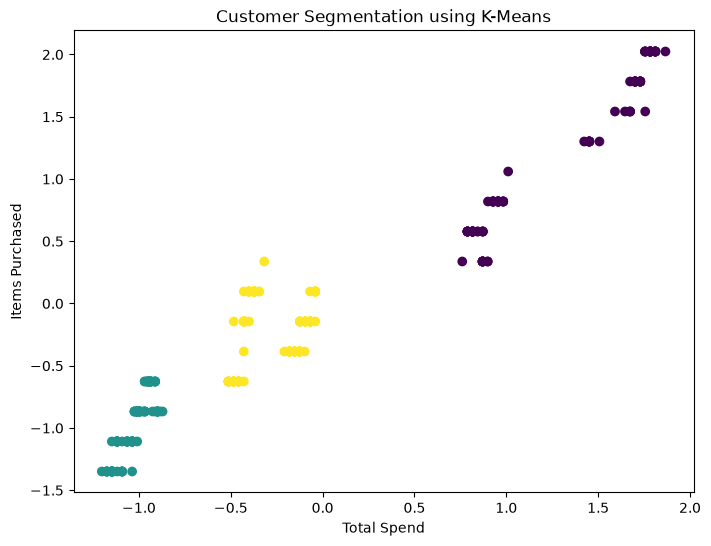

In [16]:
# ===========================
# Visualize Customer Clusters
# ===========================

plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data["Total Spend"],
    scaled_data["Items Purchased"],
    c=scaled_data["Cluster"]
)

plt.xlabel("Total Spend")
plt.ylabel("Items Purchased")
plt.title("Customer Segmentation using K-Means")

plt.show()

Analyze Clusters

In [17]:
# ===========================
# Cluster Analysis
# ===========================

cluster_summary = scaled_data.groupby("Cluster").mean()

print(cluster_summary)

         Customer ID    Gender       Age      City  Membership Type  \
Cluster                                                               
0          -0.009178  0.008547 -0.755372  1.168816        -0.003502   
1           0.008532 -1.000000  1.185243 -1.174674        -1.229130   
2           0.000719  0.982906 -0.419741 -0.004182         1.222126   

         Total Spend  Items Purchased  Average Rating  Discount Applied  \
Cluster                                                                   
0           1.288270         1.208514        4.675214          0.504274   
1          -1.028909        -0.990019        3.325000          0.500000   
2          -0.268156        -0.226957        4.051282          0.495726   

         Days Since Last Purchase  Satisfaction Level  
Cluster                                                
0                       -0.644364           -0.045768  
1                        0.374285            0.017967  
2                        0.273279           

Model Comparison

In [18]:
# ===========================
# Model Comparison
# ===========================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],
    "Metric": [
        "R² Score",
        "Accuracy"
    ],
    "Score": [
        r2,
        accuracy
    ]
})

comparison

,Model,Metric,Score
0,Linear Regression,R² Score,0.947165
1,Logistic Regression,Accuracy,0.985714


Business Interpretation

In [19]:
# ===========================
# Business Interpretation
# ===========================

print("""
Business Interpretation

1. Linear Regression predicts customer Average Rating based on
   customer spending and purchasing behaviour.

2. Logistic Regression predicts whether a customer received
   a discount.

3. GridSearchCV improves Logistic Regression by selecting
   the best hyperparameters.

4. K-Means groups customers into three different segments.

5. Customer segmentation helps businesses design targeted
   marketing campaigns and improve customer retention.
""")


Business Interpretation

1. Linear Regression predicts customer Average Rating based on
   customer spending and purchasing behaviour.

2. Logistic Regression predicts whether a customer received
   a discount.

3. GridSearchCV improves Logistic Regression by selecting
   the best hyperparameters.

4. K-Means groups customers into three different segments.

5. Customer segmentation helps businesses design targeted
   marketing campaigns and improve customer retention.



Conclusion

In [20]:
# ===========================
# Conclusion
# ===========================

print("""
Conclusion

✔ Dataset loaded successfully.

✔ Exploratory Data Analysis completed.

✔ Data preprocessing performed using Label Encoding
  and Standard Scaling.

✔ Linear Regression model built to predict
  Average Rating.

✔ Logistic Regression model built to predict
  Discount Applied.

✔ GridSearchCV used for hyperparameter tuning.

✔ K-Means clustering successfully segmented customers.

✔ Models evaluated using R² Score, RMSE,
  Accuracy, Confusion Matrix and
  Classification Report.

Task 6 completed successfully.
""")


Conclusion

✔ Dataset loaded successfully.

✔ Exploratory Data Analysis completed.

✔ Data preprocessing performed using Label Encoding
  and Standard Scaling.

✔ Linear Regression model built to predict
  Average Rating.

✔ Logistic Regression model built to predict
  Discount Applied.

✔ GridSearchCV used for hyperparameter tuning.

✔ K-Means clustering successfully segmented customers.

✔ Models evaluated using R² Score, RMSE,
  Accuracy, Confusion Matrix and
  Classification Report.

Task 6 completed successfully.

